In [1]:
import numpy as np
import matplotlib.pyplot as plt


## integrado en r con cortes en z

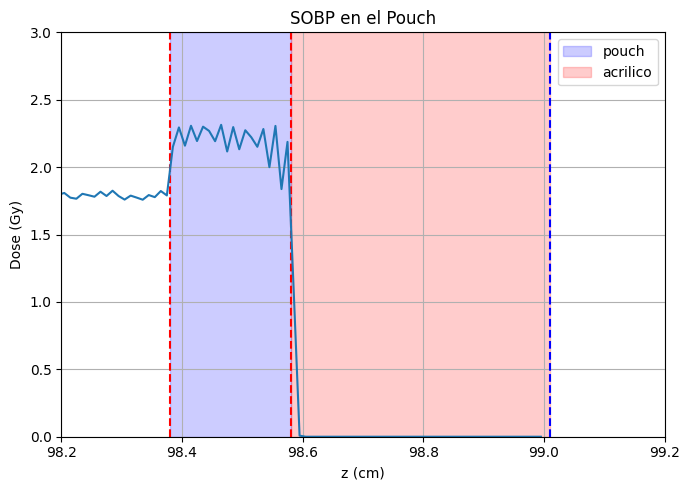

In [2]:
#DOSIS VS Z
archivo = "bragg_pouch_zcilindJesus_M0.out"

tiemporad = 300

z = []
dose = []


with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.split()


        if len(parts) != 4:
            continue


        try:
            z1 = float(parts[0].replace("D", "E"))
            z2 = float(parts[1].replace("D", "E"))
            d = float(parts[2].replace("D", "E"))
            err = float(parts[3].replace("D", "E"))
        except:
            continue


        z.append((z1 + z2) / 2)
        dose.append(d)


plt.figure(figsize=(7,5))

plt.axvline(x=98.38,color='r', linestyle='--')
plt.axvline(x=98.58, color = 'r', linestyle='--')
plt.axvline(x=99.01, color = 'b', linestyle='--')
#plt.axvline(x = 60.23, color = 'g', linestyle='--'  )

plt.axvspan(98.38, 98.58, color='b', alpha=0.2, label='pouch')
plt.axvspan(98.58, 99.01, color='r', alpha=0.2, label='acrilico')
#plt.axvspan(60.23, 60.58, color='g', alpha=0.2, label='gel de ultrasonido')

plt.legend()
plt.ylim(0, 3)
plt.xlim(98.2, 99.2)
plt.plot(z, np.array(dose)*tiemporad)
plt.xlabel("z (cm)")
plt.ylabel("Dose (Gy)") # gray por particula simulada (u)
plt.title("SOBP en el Pouch")
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
# quiero calcular las 2 posiciones en z que le corresponde a Dose = 0.122 Gy
z = np.array(z)
dose = np.array(dose)

dose_corte = 1.9/tiemporad

zcortes = []

for i in range(len(z)-1):
    if (dose[i] - dose_corte) * (dose[i+1] - dose_corte) <= 0:
        zc = z[i] + (dose_corte - dose[i]) * (z[i+1] - z[i]) / (dose[i+1] - dose[i])
        zcortes.append(zc)

print(f"Para Dose = {dose_corte} Gy, los valores de z son:")

for zc in zcortes:
    print(f"{zc:.4f} cm")

Para Dose = 0.006333333333333333 Gy, los valores de z son:
98.3781 cm
98.5637 cm
98.5668 cm
98.5777 cm


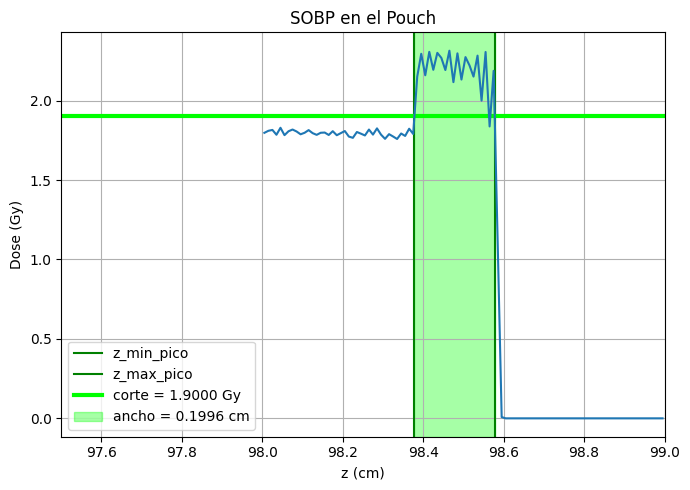

z_min = 98.3781 cm
z_max = 98.5777 cm
ancho = 0.1996 cm
ancho = 2.00 mm


In [4]:
z_pouch_min = min(zcortes)
z_pouch_max = max(zcortes)

z_pico_min = zcortes[0]
z_pico_max = zcortes[-1]

ancho_pico = z_pico_max - z_pico_min

plt.figure(figsize=(7,5))

plt.axvline(x=z_pico_min, color='green', label='z_min_pico')
plt.axvline(x=z_pico_max, color='green',  label='z_max_pico')


plt.axhline(dose_corte*tiemporad, color='lime', linewidth=3, label=f'corte = {dose_corte*tiemporad:.4f} Gy')
plt.axvspan(z_pico_min, z_pico_max, color='lime', alpha=0.35, label=f'ancho = {ancho_pico:.4f} cm')

plt.plot(z, dose*tiemporad)

plt.xlim(97.5, 99)
plt.xlabel("z (cm)")
plt.ylabel("Dose (Gy)")
plt.title("SOBP en el Pouch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"z_min = {z_pico_min:.4f} cm")
print(f"z_max = {z_pico_max:.4f} cm")
print(f"ancho = {ancho_pico:.4f} cm")
print(f"ancho = {ancho_pico*10:.2f} mm")

## integrado en z con cortes en r

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import re

Cantidad de bins radiales leídos: 100
Dosis mínima: 2.08695
Dosis máxima: 2.8356
Dosis media: 2.2258959000000003
Error relativo medio: 0.026818000000000005


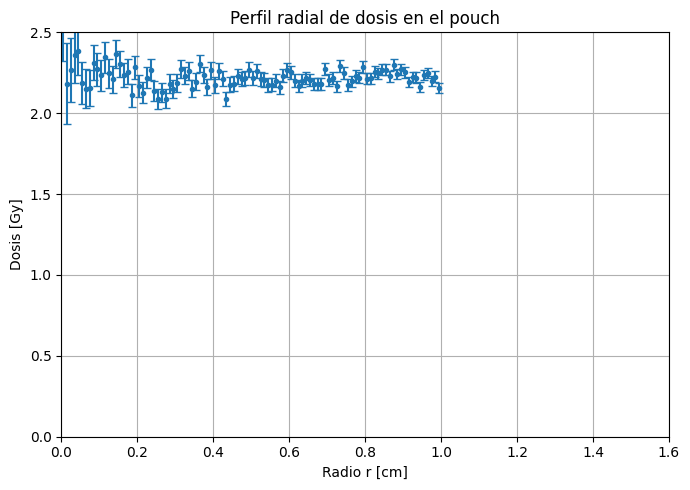

In [6]:
archivo = "bragg_pouch_rcilindJesus.out"

rmin = []
rmax = []
dosis = []
err_rel = []

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        partes = linea.split()

        if len(partes) == 4:
            try:
                r1 = float(partes[0])
                r2 = float(partes[1])
                d = float(partes[2])
                e = float(partes[3])

                if 0 <= r1 <= 1.6 and 0 <= r2 <= 1.6:
                    rmin.append(r1)
                    rmax.append(r2)
                    dosis.append(d)
                    err_rel.append(e)

            except ValueError:
                pass

rmin = np.array(rmin)
rmax = np.array(rmax)
dosis = np.array(dosis)
err_rel = np.array(err_rel)

print("Cantidad de bins radiales leídos:", len(dosis))

if len(dosis) == 0:
    raise ValueError("No se leyó ningún dato. Revisá el formato del archivo.")

r_centro = 0.5 * (rmin + rmax)
err_abs = dosis * err_rel

dosis_fisica = dosis * 300
err_abs_fisica = err_abs * 300

print("Dosis mínima:", np.min(dosis_fisica))
print("Dosis máxima:", np.max(dosis_fisica))
print("Dosis media:", np.mean(dosis_fisica))
print("Error relativo medio:", np.mean(err_rel))

plt.figure(figsize=(7, 5))

plt.errorbar(
    r_centro,
    dosis_fisica,
    yerr=err_abs_fisica,
    fmt=".",
    capsize=3
)

plt.xlabel("Radio r [cm]")
plt.ylabel("Dosis [Gy]")
plt.ylim(0, 2.5)
plt.xlim(0, 1.6)
plt.title("Perfil radial de dosis en el pouch")
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
factor = 300
dosis_graf = dosis * factor

media = np.mean(dosis_graf)
desvio = np.std(dosis_graf)
cv = 100 * desvio / media

d_min = np.min(dosis_graf)
d_max = np.max(dosis_graf)

homogeneidad_min_max = 100 * (1 - (d_max - d_min) / media)

print("===== HOMOGENEIDAD RADIAL =====")
print(f"Dosis media: {media:.4f} Gy")
print(f"Desviación estándar: {desvio:.4f} Gy")
print(f"Coeficiente de variación: {cv:.2f} %")
print(f"Dosis mínima: {d_min:.4f} Gy")
print(f"Dosis máxima: {d_max:.4f} Gy")
print(f"Rango relativo respecto a la media: {100*(d_max-d_min)/media:.2f} %")

===== HOMOGENEIDAD RADIAL =====
Dosis media: 2.2259 Gy
Desviación estándar: 0.0836 Gy
Coeficiente de variación: 3.75 %
Dosis mínima: 2.0869 Gy
Dosis máxima: 2.8356 Gy
Rango relativo respecto a la media: 33.63 %
